<a href="https://colab.research.google.com/github/ctr/medical-physics-demos-2026-03/blob/main/MedPhys_FID.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Example FID
For Prof Chris Rodgers' Medical Physics lecture. Based on materials from the Ph.D. Training program of the German Chapter of the ISMRM
https://github.com/pulseq/MR-Physics-with-Pulseq/tree/main/tutorials/01_basic_sequences/notebooks

In [1]:
# Setup only on Google Colab.
# If you run locally, install the packages in a new virtual environment, preferably with CONDA and if not with pip.
import importlib.util
import os

if os.getenv("COLAB_RELEASE_TAG"):
    print("Running in Colab - auto-installing dependencies")

    if importlib.util.find_spec("pypulseq") is None:
        get_ipython().run_line_magic(
            "pip",
            "install -q --progress-bar off pypulseq==1.4.2.post1 MRzeroCore==0.4.6 sigpy==0.1.27"
        )
    else:
        print("pypulseq is already installed.")
    get_ipython().run_line_magic("wget", "https://raw.githubusercontent.com/pulseq/MR-Physics-with-Pulseq/main/utils/utils.py > /dev/null 2>&1")
else:
   print("NOT in Colab, please check dependencies and install them in a new virtual environment as required")
   import showPackageVersions
   showPackageVersions.showPackageVersions()

#!pip show pypulseq || pip install pypulseq==1.4.2.post1 MRzeroCore==0.4.6 sigpy==0.1.27
#!wget https://raw.githubusercontent.com/pulseq/MR-Physics-with-Pulseq/main/utils/utils.py > /dev/null 2>&1

NOT in Colab, please check dependencies and install them in a new virtual environment as required
pypulseq:
  Version: 1.4.2.post1
  Location: /home/ctr28/miniconda3/envs/mrzero/lib/python3.13/site-packages
  Installer: unknown
MRzeroCore:
  Version: 0.4.6
  Location: /home/ctr28/miniconda3/envs/mrzero/lib/python3.13/site-packages
  Installer: unknown
sigpy:
  Version: 0.1.27
  Location: /home/ctr28/miniconda3/envs/mrzero/lib/python3.13/site-packages
  Installer: unknown


In [ ]:
import math
import warnings
import numpy as np
from matplotlib import pyplot as plt
import pypulseq as mr
import utils # several helper functions for simulation and recon

In [ ]:
# define high level parameters

fov=256e-3
dwell=10e-5
Nread=1024
Nphase=1
TE=5e-3
TR=60e-3

# SETUP
# Set system limits
system = mr.Opts(
    max_grad=32,
    grad_unit="mT/m",
    max_slew=130,
    slew_unit="T/m/s",
    rf_ringdown_time=30e-6,
    rf_dead_time=100e-6,
)

# Create 90 degree slice selection pulse and gradient
rf_ex, gz1, _ = mr.make_sinc_pulse(
    flip_angle=90 * np.pi / 180,
    system=system,
    duration=1e-3,
    slice_thickness=5e-3,
    apodization=0.5,
    time_bw_product=4,
    phase_offset=0* np.pi / 180,
    return_gz=True,
)


print(f"""The bandwidth is {1/dwell:.2f} Hz
and {1/(dwell*Nread):.2f} Hz/px for the {Nread*dwell*1000:.2f} ms ADC.""")

adc = mr.make_adc(
    num_samples=Nread,
    duration=Nread*dwell,
    phase_offset=0* np.pi / 180,
    system=system,)


The bandwidth is 10000.00 Hz
and 9.77 Hz/px for the 102.40 ms ADC.


/tmp/ipykernel_343/1451920464.py:22: UserWarning: Specified RF delay 0.00 us is less than the dead time 100 us. Delay was increased to the dead time.
  rf_ex, gz1, _ = mr.make_sinc_pulse(


In [ ]:
# CONSTRUCT SEQUENCE
# Create a new sequence object
seq = mr.Sequence(system)
seq.add_block(rf_ex)
seq.add_block(adc)

In [ ]:
# check sequence timing
(ok, error_report) = seq.check_timing()  # Check whether the timing of the sequence is correct
if ok:
    print("Timing check passed successfully")
else:
    print("Timing check failed. Error listing follows:")
    [print(e) for e in error_report]

Timing check passed successfully


#Visualization and Export

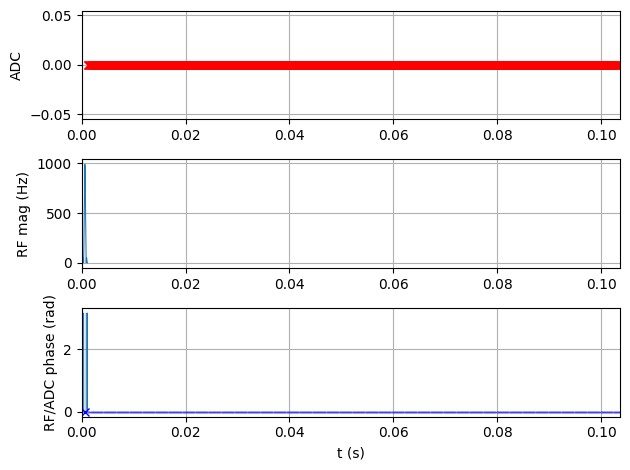

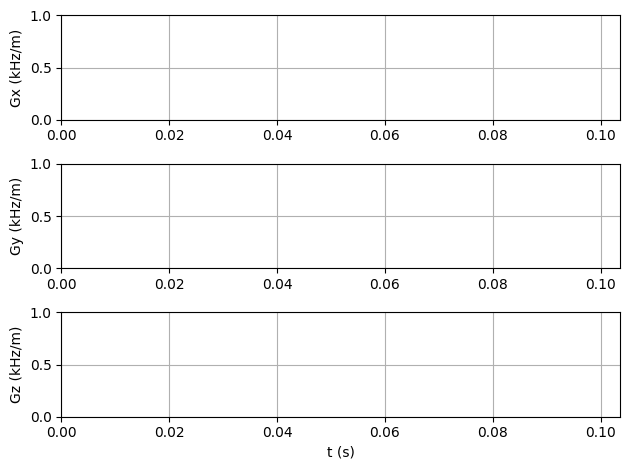

zoom in


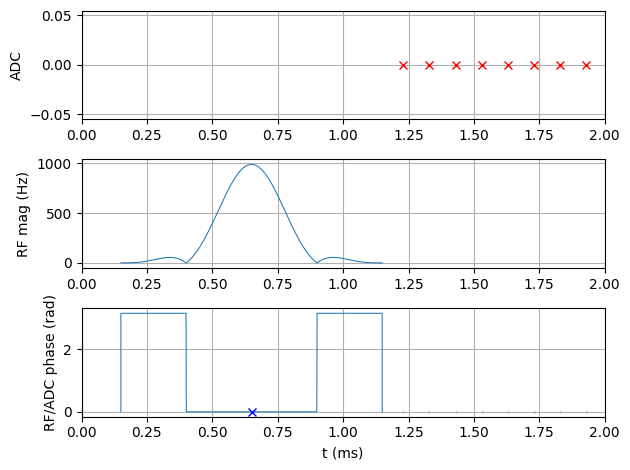

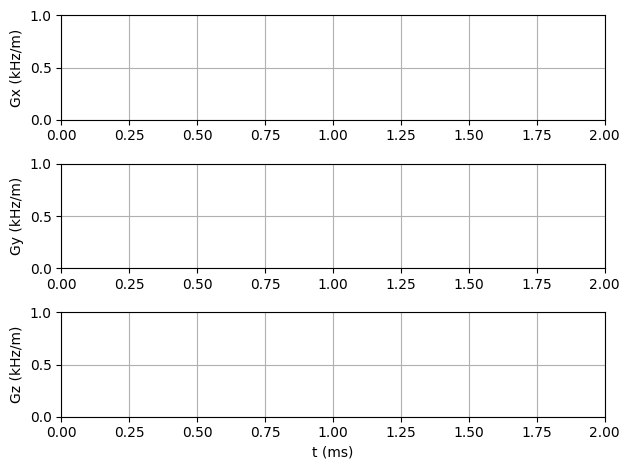

In [ ]:
#@title plot sequence
# plot the entire sequence
seq.plot()


# plot just a small initial part
print('zoom in')
seq.plot(time_range=[0, 0.002], time_disp="ms") #


In [ ]:
#@title write seq file and export
seq_filename='FID.seq'
seq.write(seq_filename)

# Uncomment lines below if you want to make your browser offer to download the generated pulseq.seq file e.g. to run on a real scanner.
#from google.colab import files
#files.download(seq_filename)  # Download locally

'98495c4651aecf09221d7ee36e26d404'

#Simulation

In [ ]:
#@title simulation setup
!pip install MRzeroCore &> /dev/null
!wget https://github.com/MRsources/MRzero-Core/raw/main/documentation/playground_mr0/numerical_brain_cropped.mat &> /dev/null
import MRzeroCore as mr0
import importlib
importlib.reload(utils) # Reload utils to recognize MRzeroCore

<module 'utils' from '/content/utils.py'>

Calculating repetition 1 / 1 - done


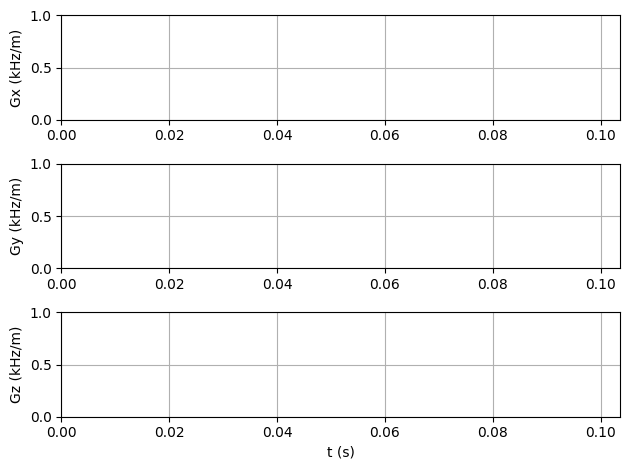

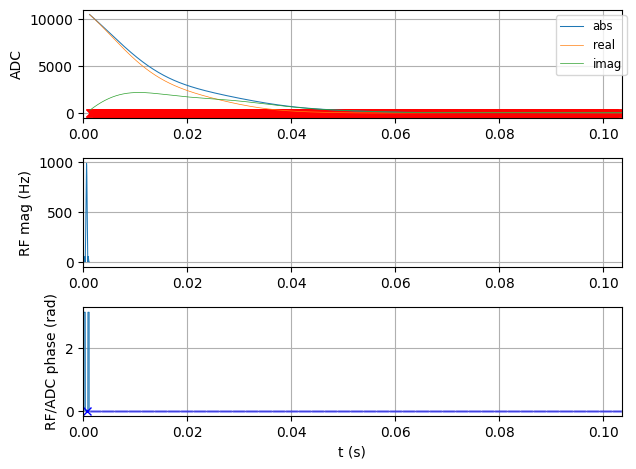

In [ ]:
#@title simulation (simple)
# kscape_adc.shape is [N_coils, N_meas, N_adc]
kspace_adc=utils.simulate_2d(seq, noise_level=0, n_coils=1, dB0=+10, B0_scale=1, B0_polynomial=None)
#sp_adc, t_adc = util.pulseq_plot(seq,signal=kspace_adc) # for pypulseq below dev branch.
seq.plot(plot_now=False)
mr0.util.insert_signal_plot(seq, kspace_adc)
plt.show()


/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2197: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  return self._math_expression.parseString(toks[0][1:-1], parseAll=True)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


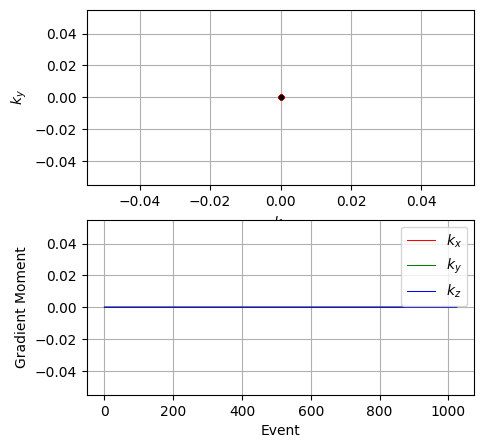

Calculating repetition 1 / 1 - done


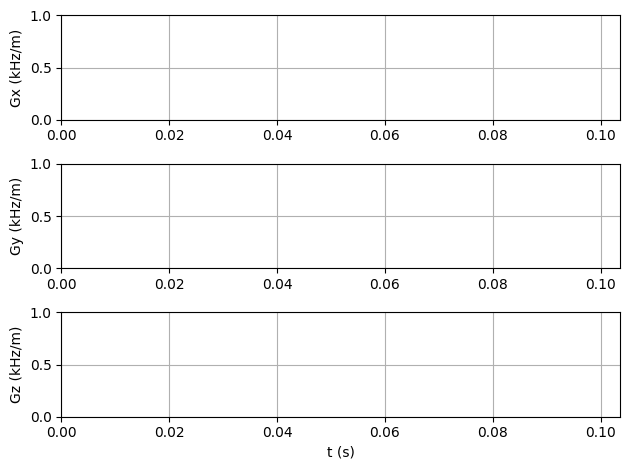

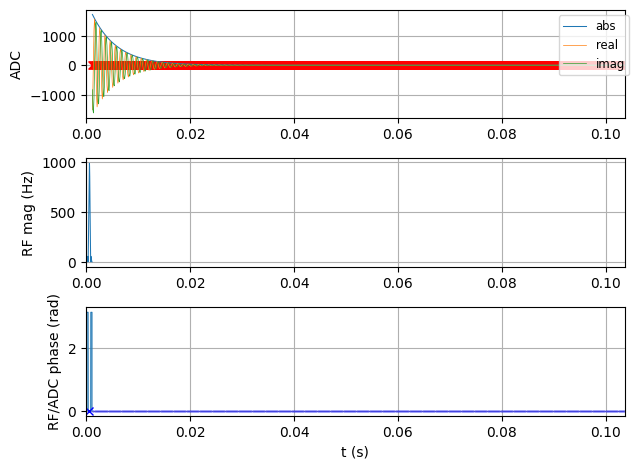

In [ ]:
#@title simulation (advanced)
# %% S4: SETUP SPIN SYSTEM/object on which we can run the seq seq_filename
sz = [64, 64]

# (i) load a phantom object from file
obj_p = mr0.VoxelGridPhantom.load_mat('numerical_brain_cropped.mat')
obj_p = obj_p.interpolate(sz[0], sz[1], 1)
# Manipulate loaded data
obj_p.T2dash[:] = 5e-3
obj_p.D *= 0
obj_p.B0 = obj_p.B0*0+1000    # alter the B0 inhomogeneity
# Store PD for comparison
PD = obj_p.PD
B0 = obj_p.B0

# obj_p.plot() # Don't plot
# Convert Phantom into simulation data
obj_p = obj_p.build()


# %% S5:. SIMULATE  the external.seq file and add acquired signal to ADC plot

# Read in the sequence
seq0 = mr0.Sequence.import_file(seq_filename)
seq0.plot_kspace_trajectory()
# Simulate the sequence
graph = mr0.compute_graph(seq0, obj_p, max_state_count=1000, min_state_mag=1e-5)
signal = mr0.execute_graph(graph, seq0, obj_p)

# PLOT sequence with signal in the ADC subplot
#sp_adc, t_adc = util.pulseq_plot(seq,signal=kspace_adc) # for pypulseq below dev branch.
seq.plot(plot_now=False)
mr0.util.insert_signal_plot(seq, signal)
plt.show()

In [ ]:
#@title Define a python equivalent to OXSA specFft.m
#import numpy as np

def specFft(fid, dim=0):
    """
    Process a free induction decay (FID) array like the MATLAB code.

    Parameters
    ----------
    fid : np.ndarray
        Input multidimensional FID array.
    dim : int, optional
        Dimension along which to perform FFT. Default is 0 (first axis).

    Returns
    -------
    spec : np.ndarray
        Processed spectrum.
    """
    # Ensure dim is within range
    dim = dim % fid.ndim

    # Move the transform dimension to the first axis
    spec = np.moveaxis(fid, dim, 0)

    # Scale t=0 point
    spec[0, ...] *= 0.5

    # FFT along first axis and shift zero-frequency to center
    spec = np.fft.fftshift(np.fft.fft(spec, axis=0), axes=0)

    # Normalize
    spec /= spec.shape[0]

    # Move the axes back to original order
    spec = np.moveaxis(spec, 0, dim)

    return spec

def specPpmAxis(spectra, dwell_time):
    """
    Compute the frequency axis (Hz) for a spectrum.

    Parameters
    ----------
    spectra : np.ndarray
        2D or ND array where the first dimension is the time dimension.
    dwell_time : float
        Dwell time in seconds.

    Returns
    -------
    freq_axis : np.ndarray
        Frequency axis in Hz.
    """
    n_points = spectra.shape[0]
    tmp = n_points / 2

    # Frequency axis
    freq_axis = np.arange(-tmp, tmp) / (dwell_time * tmp * 2)

    return freq_axis

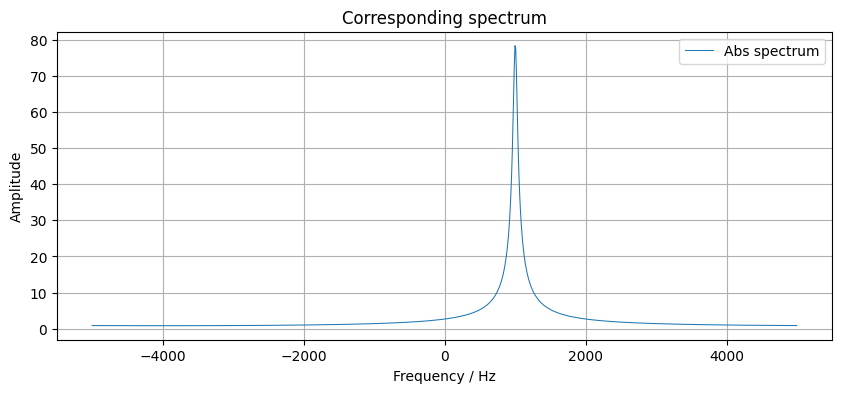

In [ ]:
#@title Inverse Fourier transform to show spectrum

# Compute the IFFT to get the time-domain signal
spectrum = specFft(signal.numpy())
ppmAxis = specPpmAxis(spectrum, dwell)

# Plot corresponding spectrum
plt.figure(figsize=(10, 4))
plt.plot(ppmAxis, np.abs(spectrum), label='Abs spectrum')
plt.title("Corresponding spectrum")
plt.xlabel("Frequency / Hz")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()